# 01 - Quickstart: CPU vs GPU Timing + Truncation Accuracy

This notebook answers two practical questions:
1. How much faster is evaluation on GPU vs CPU?
2. How do truncation knobs change speed and exactness?

Core objects:
- `circuit`: parameterized quantum program (`CliffordGate` + `PauliRotation`)
- `observables`: target operators whose expectation values we evaluate
- `program = compile_expval_program(...)`: compiled surrogate used for repeated inference


In [2]:
import os
import sys
import time

try:
    cwd = os.getcwd()
except FileNotFoundError:
    cwd = os.environ.get("PWD", os.path.expanduser("~"))

repo_root = os.path.abspath(os.path.join(cwd, "..")) if os.path.basename(cwd) == "Tutorial" else cwd
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import torch
from src.pauli_surrogate_python import PauliRotation, CliffordGate, PauliSum
from src_tensor.api import compile_expval_program

## 1) Build a benchmark circuit and observables

Why this setup:
- enough qubits/layers to make timing differences visible
- simple `Z_i` observables so errors are easy to interpret

Important variables:
- `n_qubits`: problem size (state space is `2^n`)
- `n_layers`: circuit depth
- `pidx`: number of trainable angles (`theta` length)


In [3]:
n_qubits = 10
n_layers = 2

circuit = []
pidx = 0
for _ in range(n_layers):
    for q in range(n_qubits):
        circuit.append(PauliRotation('Y', [q], param_idx=pidx)); pidx += 1
    for q in range(n_qubits):
        circuit.append(PauliRotation('Z', [q], param_idx=pidx)); pidx += 1
    for q in range(n_qubits - 1):
        circuit.append(CliffordGate('CNOT', [q, q + 1]))
    circuit.append(CliffordGate('CNOT', [n_qubits - 1, 0]))

observables = []
for q in range(n_qubits):
    o = PauliSum(n_qubits)
    o.add_from_str('Z', 1.0, qubits=[q])
    observables.append(o)

print('n_params:', pidx, 'n_observables:', len(observables), 'n_gates:', len(circuit))

n_params: 40 n_observables: 10 n_gates: 60


## 2) CPU vs GPU speed at propagate/compile stage

Here we compare **compile time** (which includes propagation) instead of expvals time.

Interpretation:
- `build_device`: where propagation runs (CPU vs GPU)
- `step_device`: where sparse steps are stored after build

This section measures `compile_expval_program(...)` wall time directly.


In [ ]:
def compile_with_timing(build_device: str):
    t0 = time.perf_counter()
    prog = compile_expval_program(
        circuit=circuit,
        observables=observables,
        preset= build_device,
    )
    if build_device.startswith('cuda') and torch.cuda.is_available():
        torch.cuda.synchronize()
    dt = time.perf_counter() - t0
    return prog, dt

def _step_nnz(psum):
    total = 0
    for st in psum.steps:
        total += int(st.mat_const._nnz()) + int(st.mat_cos._nnz()) + int(st.mat_sin._nnz())
    return total

print('Compiling CPU program...')
cpu_program, cpu_compile_s = compile_with_timing('cpu')
cpu_nnz = _step_nnz(cpu_program.psum_union)
print(f'CPU compile(propagate) time: {cpu_compile_s:.3f} s  (nnz={cpu_nnz})')

if torch.cuda.is_available():
    print('Compiling GPU program...')
    gpu_program, gpu_compile_s = compile_with_timing('gpu')
    gpu_nnz = _step_nnz(gpu_program.psum_union)
    print(f'GPU compile(propagate) time: {gpu_compile_s:.3f} s  (nnz={gpu_nnz})')
    print(f'Speedup (CPU/GPU) on compile: {cpu_compile_s / gpu_compile_s:.2f}x')
else:
    print('CUDA not available in this runtime. CPU compile timing only.')


propagate: 100%|██████████| 60/60 [00:19<00:00,  3.11it/s] 


[PPS Info] Propagation complete. Terms generated: 801,697
Starting zero-filtering on cpu...
[ZeroFilter] Initial pruning (diagonal terms only): 801,697 -> 466 terms kept (0.05812670%)
[ZeroFilter] Zero-filtering done. Starting back-propagation of keep mask through 60 steps...


zero-filter: 100%|██████████| 60/60 [00:00<00:00, 359.79it/s, step=0 rows=10 cols=10 nnz=10]     


CPU compile(propagate) time: 19.492 s  (nnz=40776)


propagate: 100%|██████████| 60/60 [00:00<00:00, 86.73it/s] 


[PPS Info] Propagation complete. Terms generated: 801,697
Starting zero-filtering on cuda...
[ZeroFilter] Initial pruning (diagonal terms only): 801,697 -> 466 terms kept (0.05812670%)
[ZeroFilter] Zero-filtering done. Starting back-propagation of keep mask through 60 steps...


zero-filter: 100%|██████████| 60/60 [00:00<00:00, 732.13it/s, step=0 rows=10 cols=10 nnz=10]

GPU compile(propagate) time: 0.941 s  (nnz=40776)
Speedup (CPU/GPU) on compile: 20.71x


## 3) Truncation sweep: `max_weight` and `build_min_abs`

Knob meaning:
- `max_weight`: drop terms with Pauli weight above this limit (structure-based truncation)
- `build_min_abs`: at compile time, drop paths whose estimated coefficient magnitude is below threshold (theta-dependent truncation)

Expected trend:
- stronger truncation -> lower nnz / faster eval
- stronger truncation -> larger error vs exact reference


In [5]:
# Use a single observable to inspect scalar error clearly
obs_exact = [observables[0]]
thetas = torch.linspace(-0.3, 0.3, pidx, dtype=torch.float64)

# Near-untruncated tensor program (for comparison)
full_prog = compile_expval_program(
    circuit=circuit,
    observables=obs_exact,
    preset='gpu',
)

exact_ref = float(full_prog.expvals_pennylane(thetas, max_qubits=20)[0].item())
tensor_full = float(full_prog.expvals(thetas)[0].item())
print('exact (PennyLane):', exact_ref)
print('tensor full       :', tensor_full, ' abs err:', abs(tensor_full - exact_ref))

propagate: 100%|██████████| 60/60 [00:00<00:00, 107.24it/s]


[PPS Info] Propagation complete. Terms generated: 523,226
Starting zero-filtering on cuda...
[ZeroFilter] Initial pruning (diagonal terms only): 523,226 -> 203 terms kept (0.03879777%)
[ZeroFilter] Zero-filtering done. Starting back-propagation of keep mask through 60 steps...


zero-filter: 100%|██████████| 60/60 [00:00<00:00, 926.05it/s, step=0 rows=1 cols=1 nnz=1]


exact (PennyLane): 0.7975231521638815
tensor full       : 0.7975231521638829  abs err: 1.4432899320127035e-15


/home/ubuntu/miniconda3/envs/pps_demo/lib/python3.11/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


In [6]:
import numpy as np
import time
import torch
import matplotlib.pyplot as plt

# 헬퍼 함수: 텐서의 Non-zero 요소 개수 계산
def _step_nnz(psum):
    total = 0
    for st in psum.steps:
        total += int(st.mat_const._nnz()) + int(st.mat_cos._nnz()) + int(st.mat_sin._nnz())
    return total

# 헬퍼 함수: 평가 시간 측정 (GPU 동기화 포함)
def _time_eval(prog, th, runs=40):
    # Warm-up
    _ = prog.expvals(th)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        
    t0 = time.perf_counter()
    for _ in range(runs):
        _ = prog.expvals(th)
        
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        
    return (time.perf_counter() - t0) / runs

# 벤치마크 설정
max_weight_values = [10]
build_min_abs_values = [None, 1e-6, 1e-5, 1e-4]

rows = []
print(f"Benchmarking {len(max_weight_values) * len(build_min_abs_values)} configurations...")

for mw in max_weight_values:
    for bma in build_min_abs_values:
        t0 = time.perf_counter()
        # 컴파일 (GPU Safe 프리셋 사용)
        prog = compile_expval_program(
            circuit=circuit,
            observables=obs_exact,
            preset='gpu',
            preset_overrides={
                'max_weight': mw,
            },
            build_thetas=thetas,
            build_min_abs=bma,
        )
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        compile_s = time.perf_counter() - t0

        # 정확도 체크
        val = float(prog.expvals(thetas)[0].item())
        err = abs(val - exact_ref)
        
        # 복잡도 체크 (NNZ)
        nnz = _step_nnz(prog.psum_union)
        
        # 속도 체크
        eval_ms = 1e3 * _time_eval(prog, thetas, runs=40)

        rows.append((mw, bma, compile_s, eval_ms, nnz, val, err))

# 결과 텍스트 출력
print('max_weight | build_min_abs | compile(s) | eval(ms) | total_nnz | abs_error')
for mw, bma, cs, ems, nnz, v, e in rows:
    print(f'{mw:>10} | {str(bma):>13} | {cs:9.3f} | {ems:8.3f} | {nnz:9d} | {e:.3e}')

Benchmarking 4 configurations...


propagate: 100%|██████████| 60/60 [00:00<00:00, 114.37it/s]


[PPS Info] Propagation complete. Terms generated: 523,226
Starting zero-filtering on cuda...
[ZeroFilter] Initial pruning (diagonal terms only): 523,226 -> 203 terms kept (0.03879777%)
[ZeroFilter] Zero-filtering done. Starting back-propagation of keep mask through 60 steps...


propagate: 100%|██████████| 60/60 [00:00<00:00, 113.98it/s]


[PPS Info] Propagation complete. Terms generated: 25,743
Starting zero-filtering on cuda...
[ZeroFilter] Initial pruning (diagonal terms only): 25,743 -> 25 terms kept (0.09711378%)
[ZeroFilter] Zero-filtering done. Starting back-propagation of keep mask through 60 steps...


...

[PPS Info] Propagation complete. Terms generated: 8,261
Starting zero-filtering on cuda...
[ZeroFilter] Initial pruning (diagonal terms only): 8,261 -> 15 terms kept (0.18157608%)
[ZeroFilter] Zero-filtering done. Starting back-propagation of keep mask through 60 steps...


propagate: 100%|██████████| 60/60 [00:00<00:00, 110.46it/s]


[PPS Info] Propagation complete. Terms generated: 2,139
Starting zero-filtering on cuda...
[ZeroFilter] Initial pruning (diagonal terms only): 2,139 -> 9 terms kept (0.42075736%)
[ZeroFilter] Zero-filtering done. Starting back-propagation of keep mask through 60 steps...


zero-filter: 100%|██████████| 60/60 [00:00<00:00, 997.53it/s, step=0 rows=1 cols=1 nnz=1]


max_weight | build_min_abs | compile(s) | eval(ms) | total_nnz | abs_error
        10 |          None |     0.592 |   22.306 |      8985 | 1.443e-15
        10 |         1e-06 |     0.606 |   20.976 |       371 | 7.950e-07
        10 |         1e-05 |     0.592 |   19.316 |       211 | 3.373e-05
        10 |        0.0001 |     0.608 |   17.227 |       125 | 7.319e-05


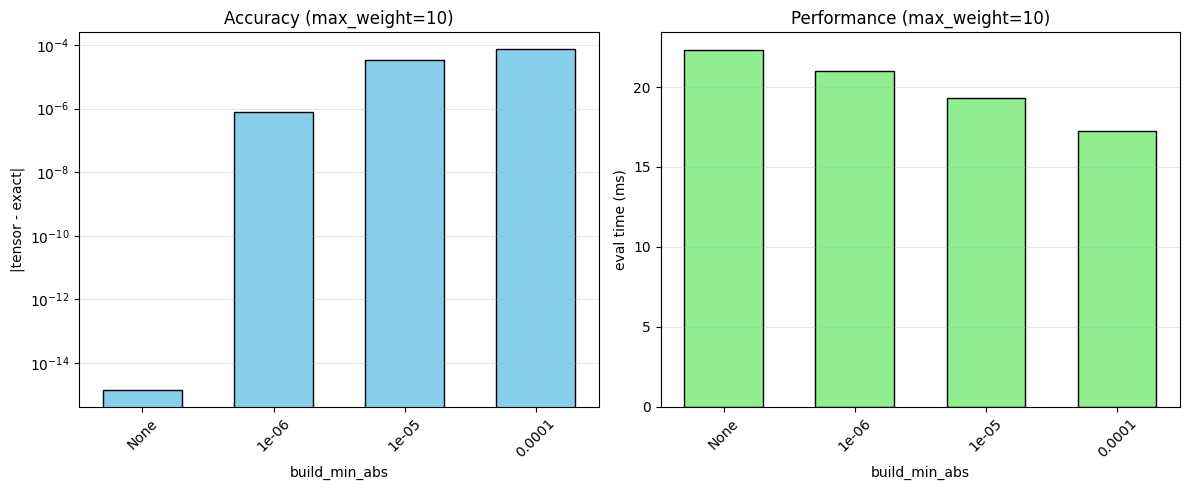

In [7]:
# Visualization (bar charts)
x_labels = [str(r[1]) for r in rows]
y_err = [r[6] for r in rows]
y_time = [r[3] for r in rows]

x_pos = np.arange(len(x_labels))
width = 0.6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. 정확도 (Error) - 로그 스케일
ax1.bar(x_pos, y_err, width, color='skyblue', edgecolor='black')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels, rotation=45)
ax1.set_xlabel('build_min_abs')
ax1.set_ylabel('|tensor - exact|')
ax1.set_yscale('log')
ax1.set_title(f'Accuracy (max_weight={max_weight_values[0]})')
ax1.grid(True, axis='y', alpha=0.3)

# 2. 성능 (Time)
ax2.bar(x_pos, y_time, width, color='lightgreen', edgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels, rotation=45)
ax2.set_xlabel('build_min_abs')
ax2.set_ylabel('eval time (ms)')
ax2.set_title(f'Performance (max_weight={max_weight_values[0]})')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Notes
- This quickstart is for **tradeoff intuition**: speed vs accuracy.
- If CUDA is unavailable, CPU-only path still provides valid results.
- Exact-reference checks use PennyLane and are practical for small qubit counts (typically <=20).
